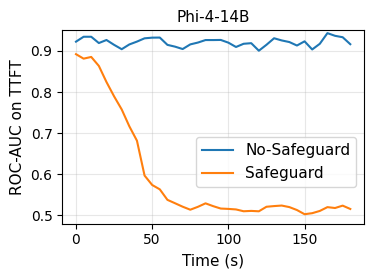

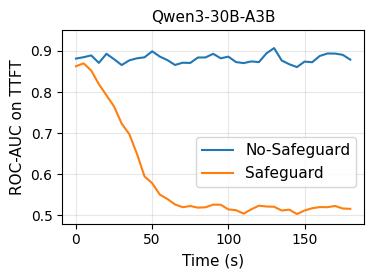

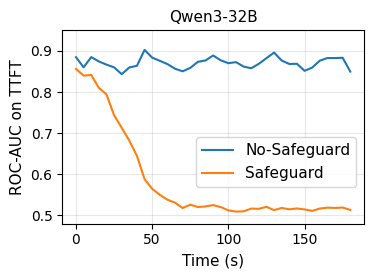

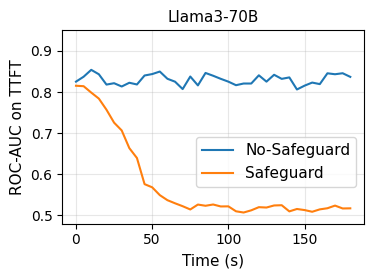

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Config (you can tune)
# -----------------------------
DT = 5                 # seconds, minimum unit
T_TOTAL = 180          # total duration in seconds (3 minutes)
W = 30                 # safeguard window in seconds (configurable)
DROP_SHARPNESS = 2.5   # higher => sharper drop after trigger
POST_AUC = 0.515       # after demotion, should be near random guess

# time axis
t = np.arange(0, T_TOTAL + DT, DT)

def logistic_drop(t, t0, pre, post=POST_AUC, sharp=DROP_SHARPNESS):
    """
    pre -> post transition around t0.
    """
    x = (t - t0) / (DT * sharp)
    s = 1 / (1 + np.exp(x))  # before t0: ~1, after t0: ~0
    return post + (pre - post) * s

def add_mean_jitter(y, seed, amp=0.01, decay_after=None):
    """
    Small oscillation + noise to mimic mean-over-runs fluctuation.
    amp kept small so we don't fake 'effects'.
    """
    rng = np.random.default_rng(seed)
    osc = amp * np.sin(2*np.pi * t / 40.0)  # ~40s mild oscillation
    noise = amp * 0.6 * rng.normal(size=len(y))
    out = y + osc + noise
    if decay_after is not None:
        mask = t > decay_after
        out[mask] = (out[mask] - POST_AUC) * 0.6 + POST_AUC  # stabilize post-trigger
    return np.clip(out, 0.5, 0.99)

# -----------------------------
# Placeholder AUC plateaus (theory-grounded ordering)
# -----------------------------
models = [
    ("Phi-4-14B",   0.92,  1),
    ("Qwen3-30B-A3B",  0.88,  2),
    ("Qwen3-32B",  0.87,  3),
    ("Llama3-70B", 0.83,  4),
]

# Define trigger time: "within one window"
# To be conservative, assume it triggers at ~W + one minimal tick (DT)
t_trigger = W + DT

# -----------------------------
# Build curves
# -----------------------------
curves = {}
for name, pre_auc, seed in models:
    # No safeguard: stays high with small jitter
    y_ns = np.full_like(t, pre_auc, dtype=float)
    y_ns = add_mean_jitter(y_ns, seed=seed, amp=0.012)

    # Safeguard on: high before trigger, then drops quickly to ~0.5
    y_sg = logistic_drop(t, t0=t_trigger, pre=pre_auc, post=POST_AUC, sharp=DROP_SHARPNESS)
    y_sg = add_mean_jitter(y_sg, seed=seed+100, amp=0.010, decay_after=t_trigger+DT)

    curves[name] = (y_ns, y_sg)

# -----------------------------
# Plot: 4 separate compact figures
# -----------------------------
for name, _, _ in models:
    y_ns, y_sg = curves[name]
    fig, ax = plt.subplots(figsize=(6.4*0.6, 4.8*0.6))
    ax.plot(t, y_ns, label="No-Safeguard", linewidth=1.5)
    ax.plot(t, y_sg, label="Safeguard", linewidth=1.5)
    # ax.axvline(t_trigger, linestyle="--", linewidth=1, color="gray")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_ylabel("ROC-AUC on TTFT", fontsize=11)
    ax.set_ylim(0.48, 0.95)
    ax.legend(loc="lower right", fontsize=11, bbox_to_anchor=(1.0, 0.15))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{name}_auc_ttft.pdf", format="pdf")
    plt.show()
